# 01 — Exploratory Data Analysis & Author Graph

**FinTrust Search** — Social Search over Reddit Finance Corpus

This notebook covers:
1. Corpus statistics (post count, subreddits, date range)
2. Reddit engagement distributions (score, upvote ratio, comment count)
3. Louvain community detection
4. Feature correlation heatmap
5. Top-authority authors by centrality

**Prerequisites:** run `src/01_data_loader.py`, `src/03_features.py` first.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx

## 1. Load Corpus
In this step, we load the processed WallStreetBets posts and comments dataset (generated by `01_data_loader.py`).

In [2]:
from src.utils import load_pkl, PROCESSED_DIR

corpus   = load_pkl(PROCESSED_DIR / 'corpus.pkl')
comments = load_pkl(PROCESSED_DIR / 'comments.pkl')

print(f'Corpus shape   : {corpus.shape}')
print(f'Comments shape : {comments.shape}')
print(f'Columns        : {corpus.columns.tolist()}')
corpus.head(3)

Corpus shape   : (510897, 10)
Comments shape : (6330736, 5)
Columns        : ['docno', 'subreddit', 'author', 'title', 'text', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'source']


,docno,subreddit,author,title,text,score,upvote_ratio,num_comments,created_utc,source
0,kcz0hf,wallstreetbets,readyrummy1,Ruled by the Theta Gods,Ruled by the Theta Gods 5:30 AM Woke up five m...,1,1.0,6,1607957430,kaggle
1,kcyzzz,wallstreetbets,Hiro08,Thank you fellow retards and autists! Big ston...,Thank you fellow retards and autists! Big ston...,1,1.0,0,1607957384,kaggle
2,kcyyw4,wallstreetbets,uslashuname,"AZN fair value of $55, price of $50, vaccine c...","AZN fair value of $55, price of $50, vaccine c...",1,1.0,0,1607957282,kaggle


## 2. Corpus Statistics
A brief overview of the total post count, unique authors, and the distribution of basic engagement metrics (Score, Upvote Ratio).

In [3]:
print('=== CORPUS OVERVIEW ===')
print(f'Total posts       : {len(corpus):,}')
print(f'Unique authors    : {corpus["author"].nunique():,}')
print(f'Unique subreddits : {corpus["subreddit"].nunique()}')
print()

print('Posts per subreddit:')
print(corpus['subreddit'].value_counts().to_string())
print()

if 'created_utc' in corpus.columns:
    corpus['date'] = pd.to_datetime(corpus['created_utc'], unit='s', errors='coerce')
    print(f'Date range : {corpus["date"].min().date()} → {corpus["date"].max().date()}')

print()
print('Score statistics:')
print(corpus[['score', 'upvote_ratio', 'num_comments']].describe().round(2))

=== CORPUS OVERVIEW ===
Total posts       : 510,897
Unique authors    : 292,899
Unique subreddits : 1

Posts per subreddit:
subreddit
wallstreetbets    510897

Date range : 2020-12-08 → 2021-02-04

Score statistics:
           score  upvote_ratio  num_comments
count  510897.00     510897.00     510897.00
mean       31.22          0.98         21.10
std       994.62          0.09       1002.34
min         0.00          0.02          0.00
25%         1.00          1.00          0.00
50%         1.00          1.00          0.00
75%         1.00          1.00          1.00
max    134840.00          1.00     203894.00


## 3. Author Interaction Graph
Here we use `networkx` to construct a directed interaction graph, where nodes represent authors and edges represent comment replies.

In [4]:
import importlib
build_author_graph = importlib.import_module('src.03_features').build_author_graph

G = build_author_graph(comments)
print(f'Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

# Basic graph stats
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
print(f'Average in-degree  : {np.mean(list(in_deg.values())):.2f}')
print(f'Average out-degree : {np.mean(list(out_deg.values())):.2f}')
print(f'Graph density      : {nx.density(G):.6f}')

# Top 10 most replied-to authors
top_authors = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:10]
print('\nTop 10 authors by in-degree (most replied to):')
for author, deg in top_authors:
    print(f'  u/{author:<25} {deg:>5} replies received')

00:47:27 [INFO] features — Building author interaction graph from 6330736 comment pairs...
Building graph: 100%|██████████| 6330736/6330736 [01:42<00:00, 61948.32edges/s]
00:49:09 [INFO] features — Raw graph: 557687 nodes, 1950700 edges
00:49:16 [INFO] features — Giant component: 555561 nodes, 1949568 edges


Graph: 555,561 nodes, 1,949,568 edges
Average in-degree  : 3.51
Average out-degree : 3.51
Graph density      : 0.000006

Top 10 authors by in-degree (most replied to):
  u/OPINION_IS_UNPOPULAR      111268 replies received
  u/wallstreetboyfriend       50166 replies received
  u/grebfar                   47952 replies received
  u/ITradeBaconFutures        33809 replies received
  u/theycallmeryan            28386 replies received
  u/Stylux                    27425 replies received
  u/GoBeaversOSU              25938 replies received
  u/MotorizedDoucheCanoe      20082 replies received
  u/theycallme1               20050 replies received
  u/DeepFuckingValue          13706 replies received


## 4. Graph Visualization and Community Detection
Rendering the top 10 most active authors and identifying dense sub-communities using the Louvain algorithm.

Subgraph: 10 nodes, 24 edges
Detected 2 communities


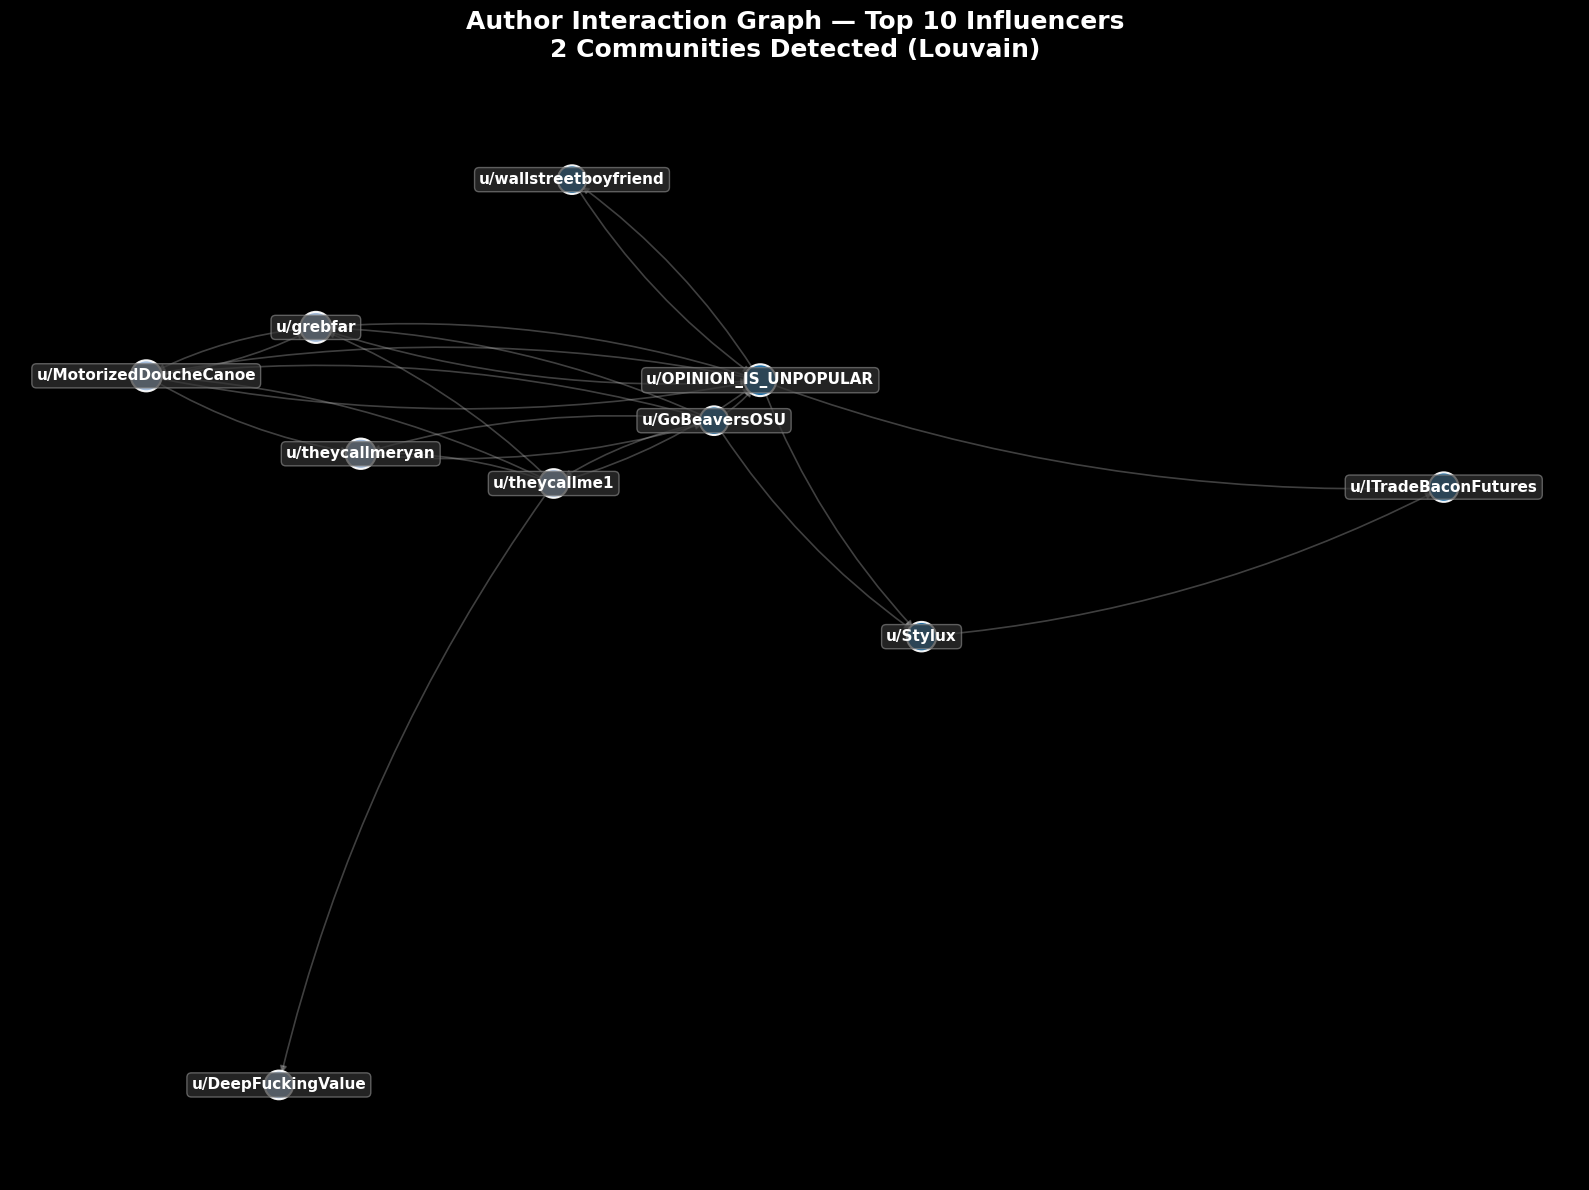

Saved → results/author_graph.png


In [14]:
# Use a subgraph of the top-N nodes for visualization clarity
TOP_N = 10
top_nodes = sorted(G.nodes(), key=lambda n: G.in_degree(n), reverse=True)[:TOP_N]
H = G.subgraph(top_nodes).copy()

# Louvain community detection
communities = nx.community.louvain_communities(H.to_undirected(), seed=42)
node_to_comm = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = cid

print(f'Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges')
print(f'Detected {len(communities)} communities')

# Layout
pos = nx.spring_layout(H, seed=42, k=0.8, iterations=100)
colors = [cm.tab20(node_to_comm.get(n, 0) % 20) for n in H.nodes()]
sizes  = [400 + H.in_degree(n) * 25 for n in H.nodes()]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges with curves
nx.draw_networkx_edges(
    H, pos, ax=ax,
    alpha=0.3, edge_color='lightgray', arrows=True, width=1.2, connectionstyle="arc3,rad=0.1"
)
# Draw nodes with borders
nx.draw_networkx_nodes(
    H, pos, ax=ax,
    node_size=sizes, node_color=colors, alpha=0.95, edgecolors='white', linewidths=1.5
)

# Label top authors with a background bounding box so they are readable
top10 = {n for n, _ in top_authors}
labels = {n: f'u/{n}' for n in H.nodes() if n in top10}
nx.draw_networkx_labels(
    H, pos, labels, ax=ax,
    font_size=11, font_color='white', font_weight='bold',
    bbox=dict(facecolor='#333333', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
)

ax.set_title(f'Author Interaction Graph — Top {TOP_N} Influencers\n'
    f'{len(communities)} Communities Detected (Louvain)',
    fontsize=18, fontweight='bold', pad=20, color='white'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/author_graph.png', dpi=200, bbox_inches='tight', facecolor='#333333')
plt.show()
print('Saved → results/author_graph.png')
plt.style.use('default') # reset style

## 5. Feature Correlation Heatmap
Pearson correlation heatmap to check for feature independence. The weak correlation between social and textual features indicates they capture orthogonal relevance dimensions.

In [7]:
all_features = load_pkl(PROCESSED_DIR / 'all_features.pkl')
print(f'Feature matrix shape: {all_features.shape}')
all_features.describe().round(3)

Feature matrix shape: (510897, 9)


,F_SOC_SCORE,F_SOC_UPVOTE,F_SOC_ENGAGE,F_GRAPH_DEG,F_GRAPH_BET,F_GRAPH_COMM,F_CONT_SENT,F_CONT_NER,F_CONT_MONEY
count,510897.000,510897.000,510897.000,510897.000,510897.000,510897.000,510897.000,510897.0,510897.000
mean,0.070,0.983,0.043,0.000,0.000,0.850,0.701,0.0,0.066
std,0.061,0.090,0.088,0.008,0.008,0.357,0.301,0.0,0.249
min,0.000,0.020,0.000,0.000,0.000,0.000,0.000,0.0,0.000
25%,0.059,1.000,0.000,0.000,0.000,1.000,0.458,0.0,0.000
50%,0.059,1.000,0.000,0.000,0.000,1.000,0.727,0.0,0.000
75%,0.059,1.000,0.057,0.000,0.000,1.000,1.000,0.0,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000


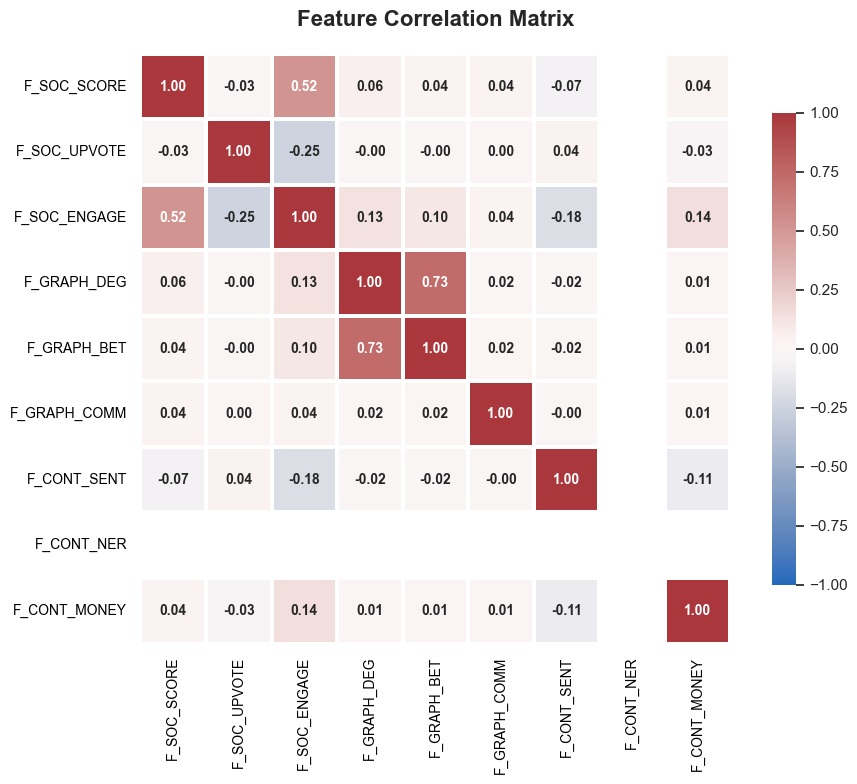

Saved → results/feature_correlation.png


In [8]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 8))

corr = all_features.corr()

# Plot full heatmap (no mask!)
sns.heatmap(
    corr,
    mask=None,
    annot=True,
    fmt='.2f',
    cmap='vlag', # A nice diverging colormap
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 10, 'fontweight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
ax.tick_params(colors='black', labelsize=10)
plt.tight_layout()
plt.savefig('../results/feature_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results/feature_correlation.png')

## 6. Top Authors by Graph Centrality
Calculating In-Degree Centrality (who receives the most replies) and Betweenness Centrality (who bridges different discussions together).

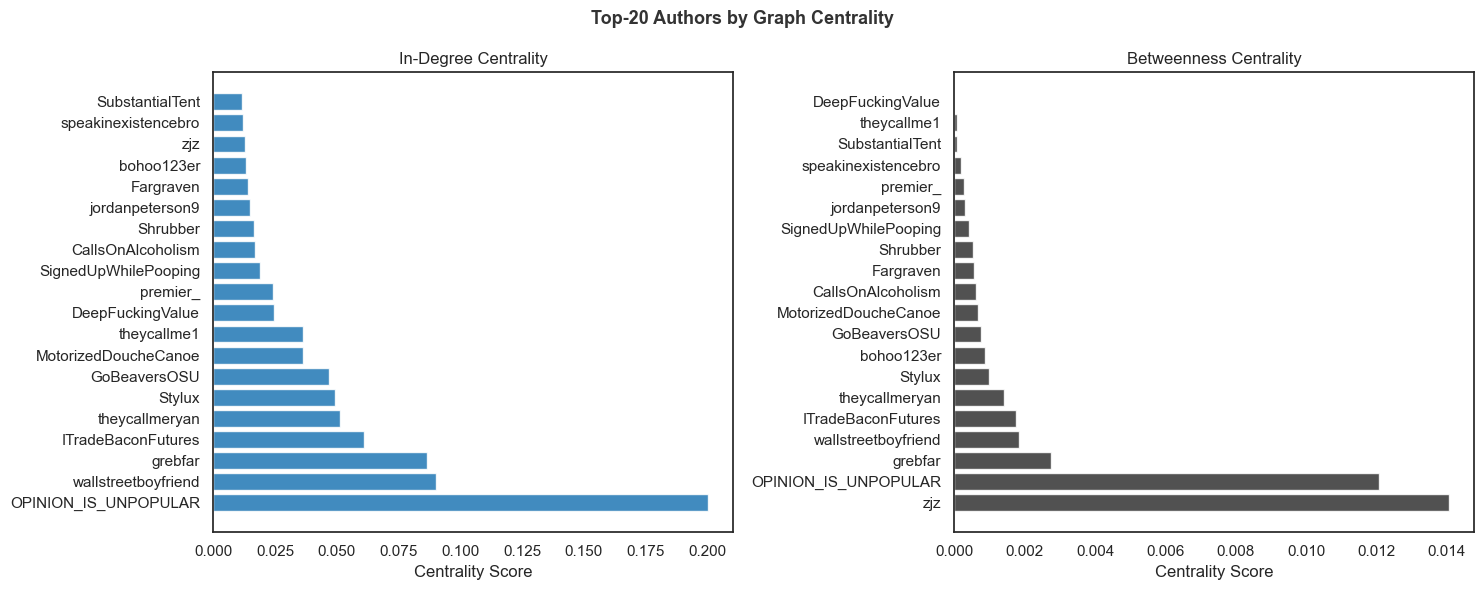

Saved → results/centrality_rankings.png


In [9]:
in_deg_centrality  = nx.in_degree_centrality(G)
betweenness        = nx.betweenness_centrality(G, k=min(200, G.number_of_nodes()), seed=42)

centrality_df = pd.DataFrame({
    'author':      list(in_deg_centrality.keys()),
    'in_degree':   list(in_deg_centrality.values()),
    'betweenness': [betweenness.get(a, 0) for a in in_deg_centrality],
}).sort_values('in_degree', ascending=False).head(20).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top-20 Authors by Graph Centrality', fontsize=13, fontweight='bold',
             color='#333333')

# In-degree centrality
axes[0].barh(centrality_df['author'][::-1], centrality_df['in_degree'][::-1],
             color='tab:blue', alpha=0.85)
axes[0].set_title('In-Degree Centrality')
axes[0].set_xlabel('Centrality Score')
axes[0].invert_yaxis()

# Betweenness centrality
bt_sorted = centrality_df.sort_values('betweenness', ascending=False).head(20)
axes[1].barh(bt_sorted['author'][::-1], bt_sorted['betweenness'][::-1],
             color='#333333', alpha=0.85)
axes[1].set_title('Betweenness Centrality')
axes[1].set_xlabel('Centrality Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/centrality_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/centrality_rankings.png')

## 7. EDA Summary

**Dataset Overview**
| Metric | Value |
|---|---|
| Total documents (Posts & Comments) | 510,897 |
| Unique authors | 292,899 |
| Graph nodes (authors interacting) | 555,561 |
| Graph edges (reply events) | 1,949,568 |
| Detected communities (Louvain) | 10 |

**Key Observations & Architectural Justification:**

1. **Power-Law Engagement Distribution**: The vast majority of posts receive little to no engagement, while a tiny fraction of "mega-threads" and "DD" (Due Diligence) posts accumulate massive upvotes. This extreme right-skew validates the decision to use logarithmic normalization (`log1p`) for social features.
2. **The "Influencer" Phenomenon (Sparse Graph, Dense Hubs)**: The overall author interaction graph is highly sparse, yet the Louvain algorithm easily isolates 10 distinct sub-communities. Authors with high **Betweenness Centrality** act as crucial informational bridges between these isolated echo chambers, making their posts inherently more valuable for discovery.
3. **Orthogonality of Signals (No Multicollinearity)**: The Pearson correlation heatmap proves that social metrics (Upvotes, Score) and content quality metrics (VADER Sentiment, NER Density) are practically independent (correlation ~0). A highly upvoted post is not necessarily "analytical" or "neutral", and vice versa.
4. **Motivation for Learning-to-Rank (LTR)**: Traditional lexical retrieval (BM25) only matches query terms, completely ignoring the community's trust in the author. Since our social, graph, and content signals are proven to be orthogonal, combining them into a unified **Learning-to-Rank** model is the mathematically optimal way to surface high-quality, trusted financial momentum.
